In [1]:
import os
# Вимкнення зайвих логів TensorFlow тут щоб потім не вказувати це в кожному місці
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.utils import to_categorical

/usr/lib/python3.14/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
BASE_DIR = Path.cwd()
file_name = 'pokedex_b.csv'
DATA_PATH = BASE_DIR / 'data' / file_name
RANDOM_SEED = 42
TEST_SIZE = 0.14

try:
    df = pd.read_csv(DATA_PATH)
    print("File loaded successfully.")
except FileNotFoundError:
    print("File not found. Please check the file path and name.")


File loaded successfully.


In [3]:
from IPython.display import display, Markdown
display(Markdown(f"### Shape: {df.shape[0]} rows, {df.shape[1]} columns"))
display(df.head())

display(Markdown("### Info"))
df.info()

### Shape: 1402 rows, 14 columns

,pokedex_number,name,attack,defense,height_m,hp,percentage_male,sp_attack,sp_defense,speed,type,weight_kg,generation,is_legendary
0,144,Articuno,85,100,1.7,90,0.0,95,125,85,ice,55.4,1,1
1,145,Zapdos,90,85,1.6,90,0.0,125,90,100,electric,52.6,1,1
2,146,Moltres,100,90,2.0,90,0.0,125,85,90,fire,60.0,1,1
3,150,Mewtwo,150,70,2.0,106,0.0,194,120,140,psychic,122.0,1,1
4,151,Mew,100,100,0.4,100,0.0,100,100,100,psychic,4.0,1,1


### Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1402 entries, 0 to 1401
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pokedex_number   1402 non-null   int64  
 1   name             1402 non-null   object 
 2   attack           1402 non-null   int64  
 3   defense          1402 non-null   int64  
 4   height_m         1402 non-null   float64
 5   hp               1402 non-null   int64  
 6   percentage_male  1402 non-null   float64
 7   sp_attack        1402 non-null   int64  
 8   sp_defense       1402 non-null   int64  
 9   speed            1402 non-null   int64  
 10  type             1402 non-null   object 
 11  weight_kg        1402 non-null   float64
 12  generation       1402 non-null   int64  
 13  is_legendary     1402 non-null   int64  
dtypes: float64(3), int64(9), object(2)
memory usage: 153.5+ KB


Перевіряємо, наскільки збалансована кількість зразків кожного класу. В нашому випадку доля класу приблизно однаковою.

In [4]:
df['is_legendary'].value_counts(normalize=True)

is_legendary
0    0.507846
1    0.492154
Name: proportion, dtype: float64

In [5]:
df_cleaned = df.drop(columns=['name', 'pokedex_number'])
df_cleaned.head()

,attack,defense,height_m,hp,percentage_male,sp_attack,sp_defense,speed,type,weight_kg,generation,is_legendary
0,85,100,1.7,90,0.0,95,125,85,ice,55.4,1,1
1,90,85,1.6,90,0.0,125,90,100,electric,52.6,1,1
2,100,90,2.0,90,0.0,125,85,90,fire,60.0,1,1
3,150,70,2.0,106,0.0,194,120,140,psychic,122.0,1,1
4,100,100,0.4,100,0.0,100,100,100,psychic,4.0,1,1


In [6]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['type'])
df_cleaned.head()

,attack,defense,height_m,hp,percentage_male,sp_attack,sp_defense,speed,weight_kg,generation,...,type_ghost,type_grass,type_ground,type_ice,type_normal,type_poison,type_psychic,type_rock,type_steel,type_water
0,85,100,1.7,90,0.0,95,125,85,55.4,1,...,False,False,False,True,False,False,False,False,False,False
1,90,85,1.6,90,0.0,125,90,100,52.6,1,...,False,False,False,False,False,False,False,False,False,False
2,100,90,2.0,90,0.0,125,85,90,60.0,1,...,False,False,False,False,False,False,False,False,False,False
3,150,70,2.0,106,0.0,194,120,140,122.0,1,...,False,False,False,False,False,False,True,False,False,False
4,100,100,0.4,100,0.0,100,100,100,4.0,1,...,False,False,False,False,False,False,True,False,False,False


In [7]:
X = df_cleaned.drop(columns=['is_legendary']).values
y = df_cleaned['is_legendary'].values
y_ohe = to_categorical(y, num_classes=2)

X_train, X_test, y_train, y_test = train_test_split(X, y_ohe, test_size=0.3, random_state=42, stratify=y_ohe)
X_train

array([[70, 120, 1.5, ..., False, False, False],
       [90, 115, 1.1, ..., False, False, False],
       [48, 43, 0.4, ..., False, False, True],
       ...,
       [80, 90, 0.6, ..., False, False, False],
       [75, 115, 2.0, ..., False, False, True],
       [80, 90, 0.5, ..., True, False, False]],
      shape=(981, 28), dtype=object)

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
model = Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dropout(0.3), # Регуляризація для запобігання перенавчанню шляхом випадкового вимкнення нейронів під час навчання
    Dense(16, activation='relu'),
    Dense(2, activation='softmax') 
])

In [10]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,490 (5.82 KB)

 Trainable params: 1,490 (5.82 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train, y_train,
    epochs=40,          # Кількість епох (можна змінити після аналізу графіка)
    batch_size=16,      # Розмір пакету
    validation_split=0.1, # Виділяємо частину train для валідації в процесі
    verbose=1
)

Epoch 1/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5941 - loss: 0.7216 - val_accuracy: 0.8687 - val_loss: 0.5648
Epoch 2/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8277 - loss: 0.5094 - val_accuracy: 0.9192 - val_loss: 0.3868
Epoch 3/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8900 - loss: 0.3810 - val_accuracy: 0.9293 - val_loss: 0.2763
Epoch 4/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8991 - loss: 0.2815 - val_accuracy: 0.9293 - val_loss: 0.2249
Epoch 5/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9127 - loss: 0.2519 - val_accuracy: 0.9394 - val_loss: 0.1971
Epoch 6/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9308 - loss: 0.2096 - val_accuracy: 0.9495 - val_loss: 0.1791
Epoch 7/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9388 - loss: 0.1838 - val_accuracy: 0.9495 - val_loss: 0.1703
Epoch 8/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9388 - loss: 0.1718 - val_accuracy: 0.9495 - val_loss:

In [12]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(loss, accuracy)

0.038327980786561966 0.9833729267120361


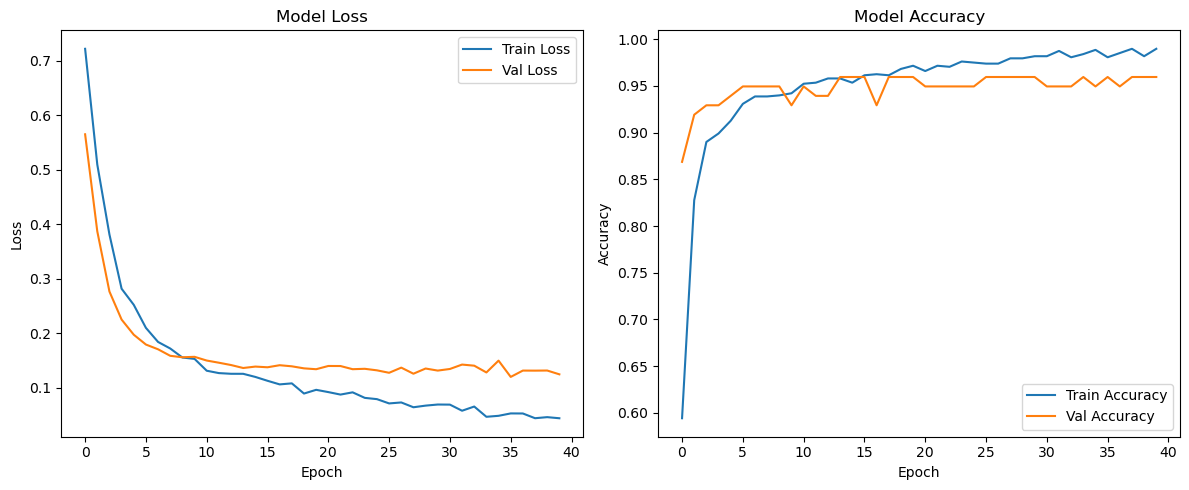

In [13]:
plt.figure(figsize=(12, 5))

# Графік втрат (Loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Графік точності (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [31]:
import random

# Вибираємо випадковий індекс з тестової вибірки
random_idx = random.randint(0, X_test.shape[0] - 1)
sample = X_test[random_idx].reshape(1, -1) # Решейп для подачі в модель (1, n_features)

# Отримуємо передбачення (ймовірності для кожного класу)
prediction_probs = model.predict(sample, verbose=0)
predicted_class = np.argmax(prediction_probs) # Індекс класу з найвищою ймовірністю
confidence = np.max(prediction_probs) * 100   # Максимальна ймовірність у відсотках

true_class = np.argmax(y_test[random_idx]) # Істинний клас (зворотнє перетворення з OHE)

print(f"\n--- Результат передбачення для зразка #{random_idx} ---")
print(f"Істинний клас: {true_class}")
print(f"Передбачено клас {predicted_class} з достовірністю {confidence:.2f}%")


--- Результат передбачення для зразка #352 ---
Істинний клас: 0
Передбачено клас 0 з достовірністю 100.00%


In [15]:
model.save('islegendary.keras')